In [6]:
from hcipy import *
from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import time
import os
import sys
import pandas as pd
sys.path.append(os.path.join(os.path.dirname(__file__), '..'))  # adds oct_2025 to sys.path

import main.params as p  # module alias
import main.utils as utils


NameError: name '__file__' is not defined

In [ ]:
utils.check_dir
wavelength_wfs=1.55e-6
wavelength_sci=1.55e-6
telescope_diameter=0.3
N=240
oversz=16.0/15.0
oversz*N
spider_w = 0.005         # [m]
D_obs =0.1       # [m]
eps = D_obs / telescope_diameter # central obscuration ratio
pupil_grid = make_pupil_grid(N*oversz, telescope_diameter * oversz)
ap_gen = make_obstructed_circular_aperture(telescope_diameter, eps, num_spiders=4, spider_width=spider_w)
ap = evaluate_supersampled(ap_gen, pupil_grid, 4) 
wf = Wavefront(ap, wavelength_sci)
wf.total_power = 1
num_airy_focal=5

In [ ]:
wf_wfs = Wavefront(ap,1.55e-6)
norm=float(wf_wfs.total_power)
print(norm)

0.06059013671875002


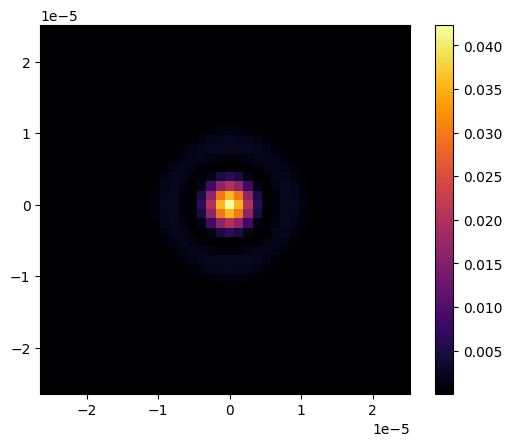

In [ ]:
spatial_resolution = wavelength_sci / telescope_diameter
focal_grid = make_focal_grid(q=4, num_airy=num_airy_focal, spatial_resolution=spatial_resolution)

propagator = FraunhoferPropagator(pupil_grid, focal_grid)

unaberrated_PSF = propagator.forward(wf).power

imshow_field(unaberrated_PSF, cmap='inferno')
plt.colorbar()
plt.show()

In [ ]:
f_number = 50
num_lenslets = 40 # 40 lenslets along one diameter
sh_diameter = 5e-3 # m

magnification = sh_diameter / telescope_diameter
magnifier = Magnifier(magnification)

In [ ]:
shwfs = SquareShackHartmannWavefrontSensorOptics(pupil_grid.scaled(magnification), f_number, \
                                                 num_lenslets, sh_diameter)
shwfse = ShackHartmannWavefrontSensorEstimator(shwfs.mla_grid, shwfs.micro_lens_array.mla_index)


In [ ]:
camera = NoiselessDetector(focal_grid)


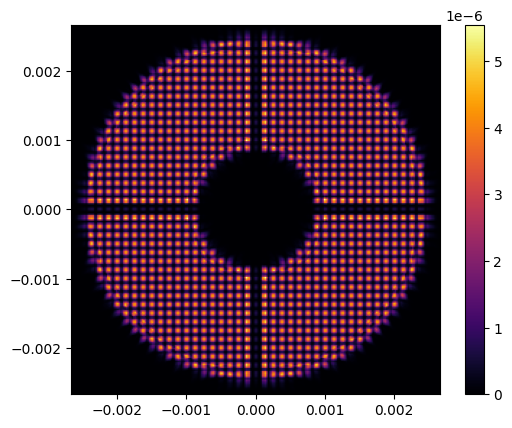

In [ ]:
wf = Wavefront(ap, wavelength_wfs)
camera.integrate(shwfs(magnifier(wf)), 1)

image_ref = camera.read_out()

imshow_field(image_ref, cmap='inferno')
plt.colorbar()
plt.show()

In [ ]:
fluxes = ndimage.measurements.sum(image_ref, shwfse.mla_index, shwfse.estimation_subapertures)
flux_limit = fluxes.max() * 0.5

estimation_subapertures = shwfs.mla_grid.zeros(dtype='bool')
estimation_subapertures[shwfse.estimation_subapertures[fluxes > flux_limit]] = True

shwfse = ShackHartmannWavefrontSensorEstimator(shwfs.mla_grid, shwfs.micro_lens_array.mla_index, estimation_subapertures)


/var/folders/fg/mh92bnm17tzb3j45vlzgdds40000gn/T/ipykernel_21703/4050218754.py:1: DeprecationWarning: Please import `sum` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  fluxes = ndimage.measurements.sum(image_ref, shwfse.mla_index, shwfse.estimation_subapertures)


In [ ]:
slopes_ref = shwfse.estimate([image_ref])


In [ ]:
num_modes = 500

dm_modes = make_disk_harmonic_basis(pupil_grid, num_modes, telescope_diameter, 'neumann')
dm_modes = ModeBasis([mode / np.ptp(mode) for mode in dm_modes], pupil_grid)

deformable_mirror = DeformableMirror(dm_modes)

In [ ]:
probe_amp = 0.01 * wavelength_wfs
response_matrix = []

wf = Wavefront(ap, wavelength_wfs)
wf.total_power = 1

# Set up animation
#plt.figure(figsize=(10, 6))
#anim = FFMpegWriter('response_matrix.mp4', framerate=5)

for i in tqdm(range(num_modes)):
    slope = 0

    # Probe the phase response
    amps = [-probe_amp, probe_amp]
    for amp in amps:
        deformable_mirror.flatten()
        deformable_mirror.actuators[i] = amp

        dm_wf = deformable_mirror.forward(wf)
        wfs_wf = shwfs(magnifier(dm_wf))

        camera.integrate(wfs_wf, 1)
        image = camera.read_out()

        slopes = shwfse.estimate([image])

        slope += amp * slopes / np.var(amps)

    response_matrix.append(slope.ravel())
    """
    # Only show all modes for the first 40 modes
    if i > 40 and (i + 1) % 20 != 0:
        continue

    # Plot mode response
    plt.clf()
    plt.suptitle('Mode %d / %d: DM shape' % (i + 1, num_modes))

    plt.subplot(1,2,1)
    plt.title('DM surface')
    im1 = imshow_field(deformable_mirror.surface, cmap='RdBu', mask=ap)

    plt.subplot(1,2,2)
    plt.title('SH spots')
    im2 = imshow_field(image)
    plt.quiver(shwfs.mla_grid.subset(shwfse.estimation_subapertures).x,
        shwfs.mla_grid.subset(shwfse.estimation_subapertures).y,
        slope[0,:], slope[1,:],
        color='white')

    #anim.add_frame()
    """
response_matrix = ModeBasis(response_matrix)

#plt.close()
#anim.close()

# Show created animation
#anim
    

  0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
rcond = 1e-3

reconstruction_matrix = inverse_tikhonov(response_matrix.transformation_matrix, rcond=rcond)
print(reconstruction_matrix.shape)

(500, 2064)


In [ ]:
reconstruction_matrix


array([[-1.83370264e-03, -6.21769196e-04,  6.53651748e-04, ...,
        -2.42807197e-03,  3.95365436e-03,  3.94346058e-03],
       [-1.24515658e-04, -2.70995202e-05,  3.15716759e-05, ...,
         3.07265857e-04, -6.94611752e-05, -1.13125756e-04],
       [ 1.48396583e-04,  2.01056878e-04,  2.64278399e-04, ...,
         6.04821643e-05, -1.86335596e-05, -5.01486030e-05],
       ...,
       [-7.36923844e-07, -7.79860017e-06, -3.39898244e-06, ...,
        -1.80586065e-05, -2.51304513e-05, -1.43617976e-05],
       [-6.43094260e-06, -4.77465004e-06,  2.36421132e-07, ...,
         1.88557644e-05,  1.95891287e-06, -8.56400522e-06],
       [ 7.12341120e-05, -6.95503748e-05, -1.71645724e-06, ...,
         1.56305953e-05,  1.23013623e-05, -1.95795513e-05]],
      shape=(500, 2064))

In [ ]:
zero_magnitude_flux = 3.9e10 #3.9e10 photon/s for a mag 0 star
stellar_magnitude = 5
delta_t = 1e-3 # sec, so a loop speed of 1kHz.

wf_wfs = Wavefront(ap, wavelength_wfs)
wf_sci = Wavefront(ap, wavelength_sci)

wf_wfs.total_power = zero_magnitude_flux * 10**(-stellar_magnitude / 2.5)
wf_sci.total_power = zero_magnitude_flux * 10**(-stellar_magnitude / 2.5)

print("Photon flux per WFS frame {:g}".format(wf_wfs.total_power * delta_t))

Photon flux per WFS frame 390000


In [ ]:
deformable_mirror.actuators = np.random.randn(num_modes) / (np.arange(num_modes) + 10)
deformable_mirror.actuators *= 0.3 * wavelength_sci / np.std(deformable_mirror.surface)

gain = 0.6
leakage = 0.01
num_iterations = 20

long_exposure = 0

# Set up animation
plt.figure(figsize=(8, 8))
anim = FFMpegWriter('AO_simulation_without_turbulence.mp4', framerate=10)

for timestep in tqdm(range(num_iterations)):
    # Propagate through SH-WFS
    wf_after_sh = shwfs(magnifier(deformable_mirror(wf_wfs)))

    # Propagate the NIR wavefront
    wf_sci_after_dm = propagator(deformable_mirror(wf_sci))

    # Read out WFS camera
    camera.integrate(wf_after_sh, delta_t)
    wfs_image = camera.read_out()
    wfs_image = large_poisson(wfs_image).astype('float')

    # Calculate slopes from WFS image
    slopes = shwfse.estimate([wfs_image + 1e-10])
    slopes -= slopes_ref
    slopes = slopes.ravel()

    # Perform wavefront control and set DM actuators
    deformable_mirror.actuators = (1 - leakage) * deformable_mirror.actuators - gain * reconstruction_matrix.dot(slopes)

    # Plotting
    plt.clf()
    plt.suptitle('Timestep %d / %d' % (timestep, num_iterations))

    plt.subplot(2,2,1)
    plt.title('DM surface [$\\mu$m]')
    imshow_field(deformable_mirror.surface * 1e6, cmap='RdBu', vmin=-1, vmax=1, mask=ap)
    plt.colorbar()

    plt.subplot(2,2,2)
    plt.title('WFS image [counts]')
    imshow_field(wfs_image, cmap='inferno')
    plt.colorbar()

    plt.subplot(2,2,3)
    plt.title('Instantaneous PSF at 2.2$\\mu$m [log]')
    imshow_field(np.log10(wf_sci_after_dm.power / wf_sci_after_dm.power.max()), vmin=-6, vmax=0, cmap='inferno')
    plt.colorbar()

    anim.add_frame()

plt.close()
anim.close()

# Show created animation
anim

  0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
num_modes

500

In [ ]:
seeing = 6 # arcsec @ 500nm (convention)
outer_scale = 40 # meter
tau0 = 0.005 # seconds


fried_parameter =0.03
Cn_squared = Cn_squared_from_fried_parameter(fried_parameter, 500e-9)
velocity = 0.314 * fried_parameter / tau0

print('r0   = {0:.1f}cm'.format(fried_parameter * 100))
print('L0   = {0:.1f}m'.format(outer_scale))
print('tau0 = {0:.1f}ms'.format(tau0 * 1000))
print('v    = {0:.1f}m/s'.format(velocity))
Cn_squared
velocity

r0   = 3.0cm
L0   = 40.0m
tau0 = 5.0ms
v    = 1.9m/s


5.1685788572890795e-12

In [ ]:
print(velocity)

NameError: name 'velocity' is not defined

In [ ]:
layer = InfiniteAtmosphericLayer(pupil_grid, Cn_squared, outer_scale, velocity,height=1)

phase_screen_phase = layer.phase_for(wavelength_wfs) # in radian
phase_screen_opd = phase_screen_phase * (wavelength_wfs / (2 * np.pi)) * 1e6

imshow_field(phase_screen_opd, vmin=-6, vmax=6, cmap='RdBu')


NameError: name 'InfiniteAtmosphericLayer' is not defined

In [ ]:
plt.figure(figsize=(5, 4))
anim = FFMpegWriter('atmospheric_turbulence.mp4', framerate=5)

t_end = 1
n = 51
for t in np.linspace(0, t_end, n):
    layer.t = t

    phase_screen_phase = layer.phase_for(wavelength_wfs) # in radian
    phase_screen_opd = phase_screen_phase * (wavelength_wfs / (2 * np.pi)) * 1e6 # in um

    plt.clf()
    plt.suptitle('Time %.3f s' % t)

    plt.subplot(1,1,1)
    plt.title('Turbulent wavefront [$\\mu$m]')
    imshow_field(phase_screen_opd, vmin=-6, vmax=6, cmap='RdBu')
    plt.colorbar()

    anim.add_frame()

plt.close()
anim.close()

# Show created animation
anim

NameError: name 'plt' is not defined

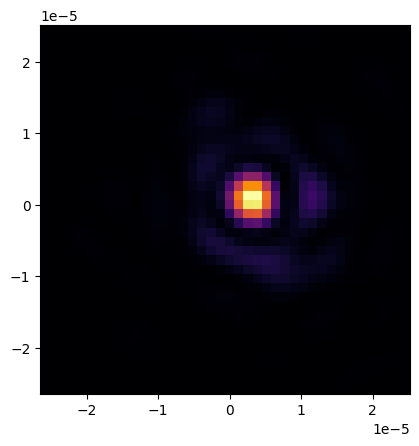

In [ ]:
#deformable_mirror.flatten()
wf_sci_focal_plane = propagator(deformable_mirror(layer(wf_sci)))
imshow_field(wf_sci_focal_plane.power , cmap='inferno')


In [ ]:
fried_parameter =0.03
Cn_squared = Cn_squared_from_fried_parameter(fried_parameter, 500e-9)
layer = InfiniteAtmosphericLayer(pupil_grid, Cn_squared, outer_scale, velocity)
layer.reset()
deformable_mirror.flatten()

gain = 0.3
leakage = 0.01
num_iterations = 750
burn_in_iterations = 5

coro = PerfectCoronagraph(ap, 4)

long_exposure = focal_grid.zeros()
long_exposure_coro = focal_grid.zeros()

# Set up animation
plt.figure(figsize=(8, 8))
anim = FFMpegWriter('AO_simulation_with_turbulence.mp4', framerate=10)

for timestep in tqdm(range(num_iterations)):
    layer.t = timestep * delta_t

    # Propagate through atmosphere and deformable mirror.
    wf_wfs_after_atmos = layer(wf_wfs)
    wf_wfs_after_dm = deformable_mirror(wf_wfs_after_atmos)

    # Propagate through SH-WFS
    wf_wfs_on_sh = shwfs(magnifier(wf_wfs_after_dm))

    # Propagate the NIR wavefront
    wf_sci_focal_plane = propagator(deformable_mirror(layer(wf_sci)))
    wf_sci_coro = propagator(coro(deformable_mirror(layer(wf_sci))))

    # Read out WFS camera
    camera.integrate(wf_wfs_on_sh, delta_t)
    wfs_image = camera.read_out()
    wfs_image = large_poisson(wfs_image).astype('float')

    # Accumulate long-exposure image
    if timestep >= burn_in_iterations:
        long_exposure += wf_sci_focal_plane.power / (num_iterations - burn_in_iterations)
        long_exposure_coro += wf_sci_coro.power / (num_iterations - burn_in_iterations)

    # Calculate slopes from WFS image
    slopes = shwfse.estimate([wfs_image + 1e-10])
    slopes -= slopes_ref
    slopes = slopes.ravel()

    # Perform wavefront control and set DM actuators
    deformable_mirror.actuators = (1 - leakage) * deformable_mirror.actuators - gain * reconstruction_matrix.dot(slopes)

    # Plotting
    if timestep % 20 == 0:
        plt.clf()

        plt.suptitle('Timestep %d / %d' % (timestep, num_iterations))

        plt.subplot(2,2,1)
        plt.title('DM surface [$\\mu$m]')
        imshow_field(deformable_mirror.surface * 1e6, cmap='RdBu', vmin=-2, vmax=2, mask=ap)
        plt.colorbar()

        plt.subplot(2,2,2)
        plt.title('WFS image [counts]') 
        imshow_field(wfs_image, cmap='inferno')
        plt.colorbar()

        plt.subplot(2,2,3)
        plt.title('Instantaneous PSF at 2.2$\\mu$m [log]')
        imshow_field(np.log10(wf_sci_focal_plane.power/ wf_sci_focal_plane.power.max()), vmin=-6, vmax=0, cmap='inferno') #
        plt.colorbar()

        if timestep >= burn_in_iterations:
            plt.subplot(2,2,4)
            plt.title('Average PSF at 2.2$\\mu$m [log]')
            imshow_field(np.log10(long_exposure_coro / long_exposure.max()), vmin=-6, vmax=0, cmap='inferno')
            plt.colorbar()

        anim.add_frame()

plt.close()
anim.close()

# Show created animation
anim


  0%|          | 0/750 [00:00<?, ?it/s]

In [ ]:
float(np.sum(wf_sci_focal_plane.power)/int(wf_wfs.total_power))

0.9066939923118744

In [ ]:
r0_ref_list=[0.01,0.05,0.03,0.07,0.2]
log_rows=[]
for r0 in r0_ref_list:
    fried_parameter =r0
    Cn_squared = Cn_squared_from_fried_parameter(fried_parameter, 500e-9)
    layer1 = InfiniteAtmosphericLayer(pupil_grid, Cn_squared, outer_scale, velocity,height=2)
    layer2 = InfiniteAtmosphericLayer(pupil_grid, Cn_squared, outer_scale, velocity,height=8)
    layer=atmos = MultiLayerAtmosphere([layer1,layer2], scintillation=True)
    layer.reset()
    deformable_mirror.flatten()
    gain = 0.3
    leakage = 0.01
    num_iterations = 800
    burn_in_iterations = 5

    coro = PerfectCoronagraph(ap, 4)

    long_exposure = focal_grid.zeros()
    long_exposure_coro = focal_grid.zeros()

    # Set up animation
    plt.figure(figsize=(8, 8))
    anim = FFMpegWriter('AO_simulation_with_turbulence.mp4', framerate=10)

    for timestep in tqdm(range(num_iterations)):
        layer.t = timestep * delta_t

        # Propagate through atmosphere and deformable mirror.
        wf_wfs_after_atmos = layer(wf_wfs)
        wf_wfs_after_dm = deformable_mirror(wf_wfs_after_atmos)

        # Propagate through SH-WFS
        wf_wfs_on_sh = shwfs(magnifier(wf_wfs_after_dm))
        wf_wfs_on_sh_non_magnifier=shwfs(wf_wfs_after_dm)
        # Propagate the NIR wavefront
        wf_sci_focal_plane = propagator(deformable_mirror(layer(wf_sci)))
        wf_sci_coro = propagator(coro(deformable_mirror(layer(wf_sci))))

        # Read out WFS camera
        camera.integrate(wf_wfs_on_sh, delta_t)
        wfs_image = camera.read_out()
        wfs_image = large_poisson(wfs_image).astype('float')

        # Accumulate long-exposure image
        if timestep >= burn_in_iterations:
            long_exposure += wf_sci_focal_plane.power / (num_iterations - burn_in_iterations)
            long_exposure_coro += wf_sci_coro.power / (num_iterations - burn_in_iterations)

        # Calculate slopes from WFS image
        slopes = shwfse.estimate([wfs_image + 1e-10])
        slopes -= slopes_ref
        slopes = slopes.ravel()

        # Perform wavefront control and set DM actuators
        deformable_mirror.actuators = (1 - leakage) * deformable_mirror.actuators - gain * reconstruction_matrix.dot(slopes)

        # Plotting
        if timestep % 20 == 0:
            E_power = float(np.sum(propagator(wf_wfs_after_atmos).power))
            D_power = float(np.sum(wf_sci_focal_plane.power))

            log_rows.append({
                "timestep": timestep,
                "E_power_sum": E_power,
                "D_power_sum": D_power,
                "num_airy":num_airy_focal,
                "r0_ref":fried_parameter,
            })
            plt.clf()
            plt.suptitle('Timestep %d / %d' % (timestep, num_iterations))

            plt.subplot(3,2,1)
            plt.title("psf at the entry [c]")
            imshow_field(wf_wfs_after_atmos.phase, cmap='inferno')
            plt.xlabel('[M]')
            plt.ylabel('[M]')
            cb1=plt.colorbar()
            cb1.set_label("[rad]")

            plt.subplot(3,2,2)
            plt.title('WFS at camera [counts][E]')
            imshow_field(np.log10(propagator(wf_wfs_after_atmos).power/propagator(wf_wfs_after_atmos).power.max()),cmap="inferno")
            plt.xlabel('[M]')
            plt.ylabel('[M]')
            cb2=plt.colorbar()
            cb2.set_label("[W]")

            plt.subplot(3,2,3)
            plt.title('DM surface [$\\mu$m]-[H]')
            imshow_field(deformable_mirror.surface * 1e6, cmap='RdBu', vmin=-2, vmax=2, mask=ap)
            plt.xlabel('[M]')
            plt.ylabel('[M]')
            cb3=plt.colorbar()
            cb3.set_label("[rad]")

            plt.subplot(3,2,4)
            plt.title(' PSF at Shack-Hartmann [F]')
            imshow_field(wfs_image,cmap='inferno')
            plt.xlabel('[M]')
            plt.ylabel('[M]')
            cb4=plt.colorbar()
            cb4.set_label("[W]")

            plt.subplot(3,2,5)
            plt.title(' PSF at focal [D]')
            imshow_field(np.log10(wf_sci_focal_plane.power / wf_sci_focal_plane.power.max()), vmin=-6, vmax=0, cmap='inferno')
            plt.xlabel('[M]')
            plt.ylabel('[M]')
            cb5=plt.colorbar()
            cb5.set_label("[W]")


            plt.tight_layout()
            anim.add_frame()

    plt.close()
    anim.close()

    # Show created animation
    anim
output_path = "AO_simulation_log.csv"
df_log = pd.DataFrame(log_rows)
if os.path.exists(output_path):
    # לקרוא את הקובץ הקיים ולהוסיף לו את השורות החדשות
    df_old = pd.read_csv(output_path)
    df_all = pd.concat([df_old, df_log], ignore_index=True)
else:
    # אם אין קובץ ישן – נתחיל חדש
    df_all = df_log

df_all.to_csv(output_path, index=False)
print("Appended log to AO_simulation_log_heights.csv")

  0%|          | 0/800 [00:00<?, ?it/s]

Appended log to AO_simulation_log_heights.csv


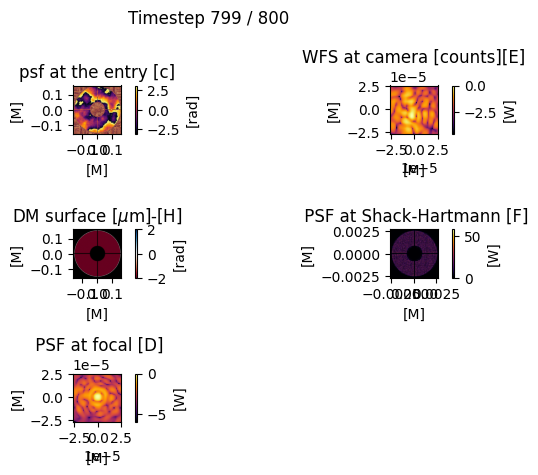

In [ ]:
plt.clf
plt.suptitle('Timestep %d / %d' % (timestep, num_iterations))

plt.subplot(3,2,1)
plt.title("psf at the entry [c]")
imshow_field(wf_wfs_after_atmos.phase, cmap='inferno')
plt.xlabel('[M]')
plt.ylabel('[M]')
cb1=plt.colorbar()
cb1.set_label("[rad]")

plt.subplot(3,2,2)
plt.title('WFS at camera [counts][E]')
imshow_field(np.log10(propagator(wf_wfs_after_atmos).power/propagator(wf_wfs_after_atmos).power.max()),cmap="inferno")
plt.xlabel('[M]')
plt.ylabel('[M]')
cb2=plt.colorbar()
cb2.set_label("[W]")

plt.subplot(3,2,3)
plt.title('DM surface [$\\mu$m]-[H]')
imshow_field(deformable_mirror.surface * 1e6, cmap='RdBu', vmin=-2, vmax=2, mask=ap)
plt.xlabel('[M]')
plt.ylabel('[M]')
cb3=plt.colorbar()
cb3.set_label("[rad]")

plt.subplot(3,2,4)
plt.title(' PSF at Shack-Hartmann [F]')
imshow_field(wfs_image,cmap='inferno')
plt.xlabel('[M]')
plt.ylabel('[M]')
cb4=plt.colorbar()
cb4.set_label("[W]")

plt.subplot(3,2,5)
plt.title(' PSF at focal [D]')
imshow_field(np.log10(wf_sci_focal_plane.power / wf_sci_focal_plane.power.max()), vmin=-6, vmax=0, cmap='inferno')
plt.xlabel('[M]')
plt.ylabel('[M]')
cb5=plt.colorbar()
cb5.set_label("[W]")


plt.tight_layout()


Found r0 values: [np.float64(0.01), np.float64(0.017), np.float64(0.03), np.float64(0.05), np.float64(0.07), np.float64(0.2)]


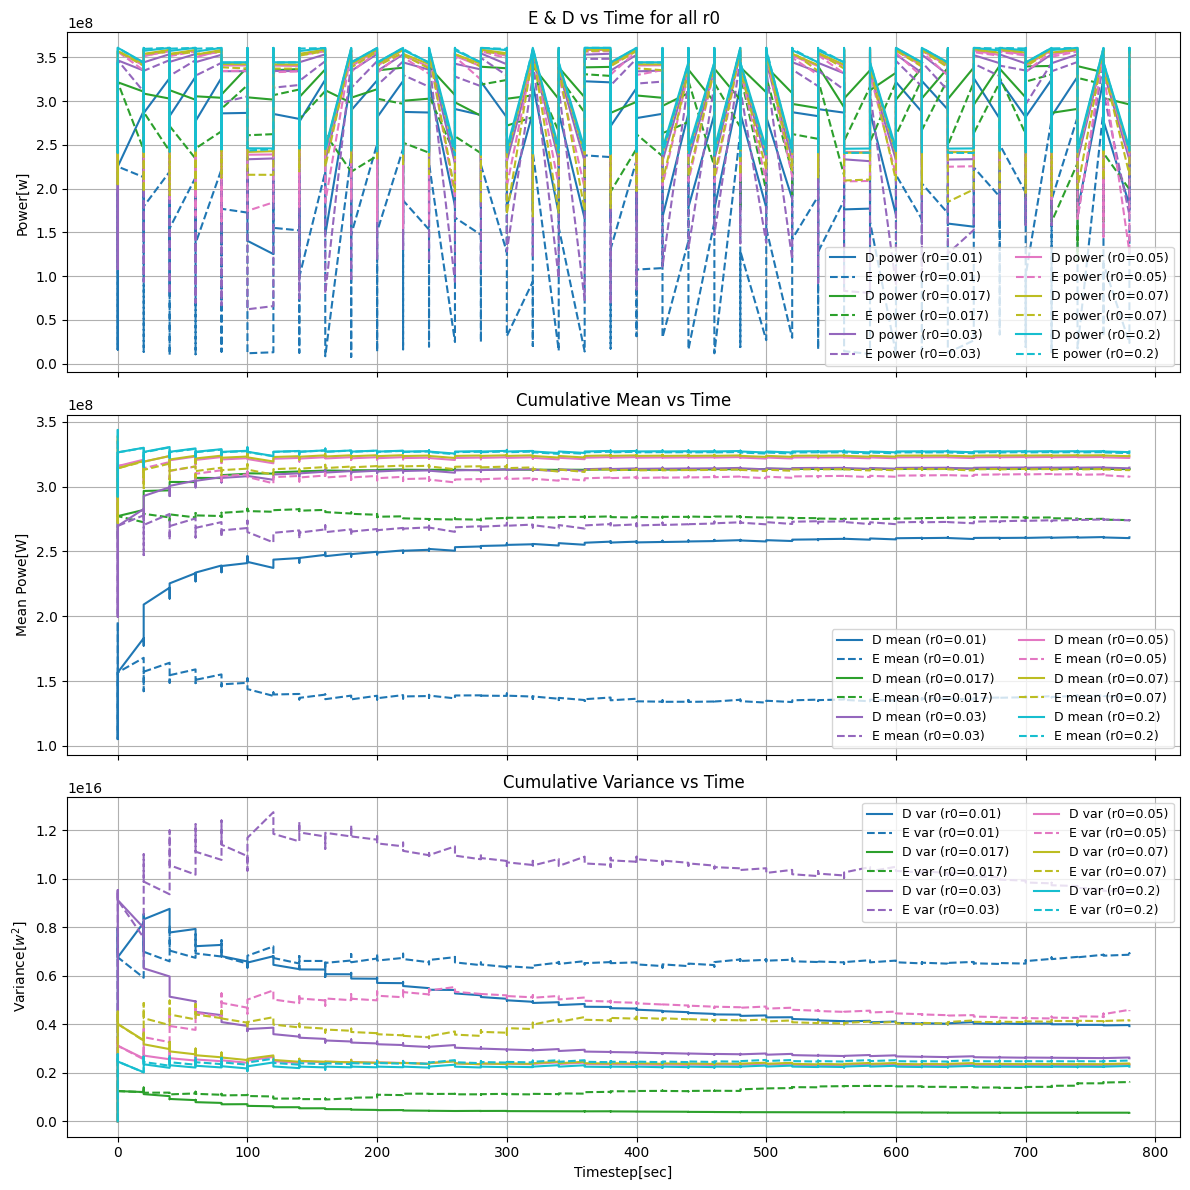

In [ ]:
# --- Load CSV ---
df = pd.read_csv("AO_simulation_log.csv")

# שמות עמודות – עדכן אם אצלך שונים
t_col  = "timestep"
E_col  = "E_power_sum"
D_col  = "D_power_sum"

# נזהה איך קוראים לעמודת r0
if "r0_ref" in df.columns:
    r0_col = "r0_ref"
elif "r0" in df.columns:
    r0_col = "r0"
else:
    raise KeyError("לא מצאתי עמודה של r0 (נסה r0_ref או r0).")

# --- Identify unique r0 values ---
unique_r0 = sorted(df[r0_col].unique())
print("Found r0 values:", unique_r0)

# --- Prepare figure with 3 subplots ---
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_r0)))  # צבע לכל r0

# ========================
# 1) E ו-D כפונקציה של זמן
# ========================
for idx, r0 in enumerate(unique_r0):
    sub = df[df[r0_col] == r0].sort_values(by=t_col)

    t = sub[t_col].values
    E = sub[E_col].values
    D = sub[D_col].values

    color = colors[idx]

    # D power = קו ישר
    ax0.plot(t, D, '-', color=color, label=f"D power (r0={r0})")
    # E power = קו מקווקו
    ax0.plot(t, E, '--', color=color, label=f"E power (r0={r0})")

ax0.set_ylabel("Power[w]")
ax0.set_title("E & D vs Time for all r0")
ax0.grid(True)
ax0.legend(ncol=2, fontsize=9)

# ============================
# 2) תוחלת בזמן (cumulative mean)
# ============================
for idx, r0 in enumerate(unique_r0):
    sub = df[df[r0_col] == r0].sort_values(by=t_col)

    t = sub[t_col].values

    # cumulative moving average לאורך הזמן
    E_mean = sub[E_col].expanding().mean()
    D_mean = sub[D_col].expanding().mean()

    color = colors[idx]

    ax1.plot(t, D_mean, '-',  color=color, label=f"D mean (r0={r0})")
    ax1.plot(t, E_mean, '--', color=color, label=f"E mean (r0={r0})")

ax1.set_ylabel("Mean Powe[W]")
ax1.set_title("Cumulative Mean vs Time")
ax1.grid(True)
ax1.legend(ncol=2, fontsize=9)

# ============================
# 3) שונות בזמן (cumulative variance)
# ============================
for idx, r0 in enumerate(unique_r0):
    sub = df[df[r0_col] == r0].sort_values(by=t_col)

    t = sub[t_col].values

    # cumulative variance לאורך הזמן
    E_var = sub[E_col].expanding().var(ddof=0)
    D_var = sub[D_col].expanding().var(ddof=0)

    color = colors[idx]

    ax2.plot(t, D_var, '-',  color=color, label=f"D var (r0={r0})")
    ax2.plot(t, E_var, '--', color=color, label=f"E var (r0={r0})")

ax2.set_xlabel("Timestep[sec]")
ax2.set_ylabel("Variance[$w^2$]")
ax2.set_title("Cumulative Variance vs Time")
ax2.grid(True)
ax2.legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
norm=int(wf_wfs.total_power)
df = pd.read_csv("AO_simulation_log.csv")
t_col   = "timestep"
E_col   = "E_power_sum"
D_col   = "D_power_sum"
r0_col  = "r0_ref"
airy_col = "num_airy"
df["ratio_DE"] = df[D_col] / df[E_col]
df["E_norm"]=df[E_col]/norm
df["D_norm"]=df[E_col]/norm


[0.3668924  0.30287648 0.1167769  0.09451267 0.01181546] 1
[0.33391037 0.12968616 0.05266248 0.0205587  0.0099821  0.00094583] 3
[ 0.27477929  0.04234499  0.02572307  0.00451773  0.00221941 -0.0025495 ] 5


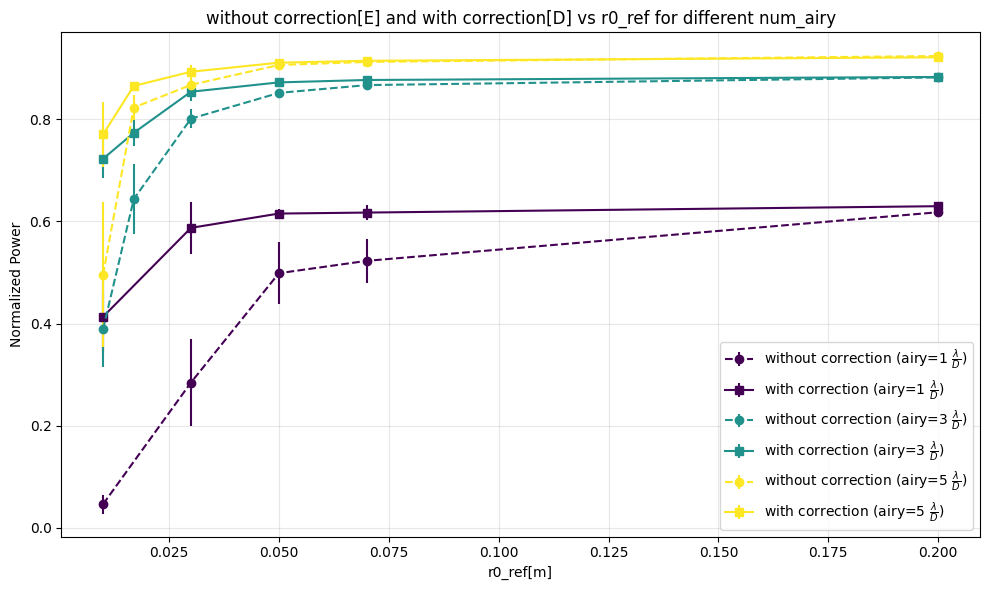

In [ ]:
# --- Load data ---
df = pd.read_csv("AO_simulation_log.csv")
norm=int(wf_wfs.total_power)
# --- Columns ---
t_col   = "timestep"
E_col   = "E_power_sum"
D_col   = "D_power_sum"
r0_col  = "r0_ref"
airy_col = "num_airy"
# --- Compute new columns ---
df["E_norm"] = df[E_col] / norm
df["D_norm"] = df[D_col] / norm  # ← תיקון: בעבר כתבת פעמיים E_col
# --- Prepare figure ---
plt.figure(figsize=(10,6))
# --- unique Airy groups ---
airy_groups = sorted(df[airy_col].unique())

# colormap
colors = plt.cm.viridis(np.linspace(0,1,len(airy_groups)))

for color, airy in zip(colors, airy_groups):

    sub = df[df[airy_col] == airy]

    # group by r0 and compute mean/std
    grouped = sub.groupby(r0_col)

    r0_vals = grouped[r0_col].mean().values
    E_mean  = grouped["E_norm"].mean().values
    E_std   = grouped["E_norm"].std().values
    D_mean  = grouped["D_norm"].mean().values
    D_std   = grouped["D_norm"].std().values
    frac_01=D_mean-E_mean
    fn_01=frac_01
    print(fn_01,airy)
    # E_norm – dashed
    plt.errorbar(r0_vals, E_mean, yerr=E_std, 
                 fmt='--o', color=color, label=f"without correction (airy={airy} $\\frac{{\\lambda}}{{D}}$)")

    # D_norm – solid
    plt.errorbar(r0_vals, D_mean, yerr=D_std, 
                 fmt='-s', color=color, label=f"with correction (airy={airy} $\\frac{{\\lambda}}{{D}}$)")    
plt.xlabel("r0_ref[m]")
plt.ylabel("Normalized Power")
plt.title("without correction[E] and with correction[D] vs r0_ref for different num_airy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


r0_ref_list=[0.01,0.05,0.03,0.07,0.2]
fn1=[0.3668924  0.30287648 0.1167769  0.09451267 0.01181546] 
fn3[0.33391037 0.05266248 0.0205587  0.0099821  0.00094583] 
fn5=[2.09558473e-01 1.85333153e-02 4.96347789e-03 4.42465487e-03
 4.96056099e-05] 

In [ ]:
wf_wfs.total_power

OldStyleField(3.9e+08)

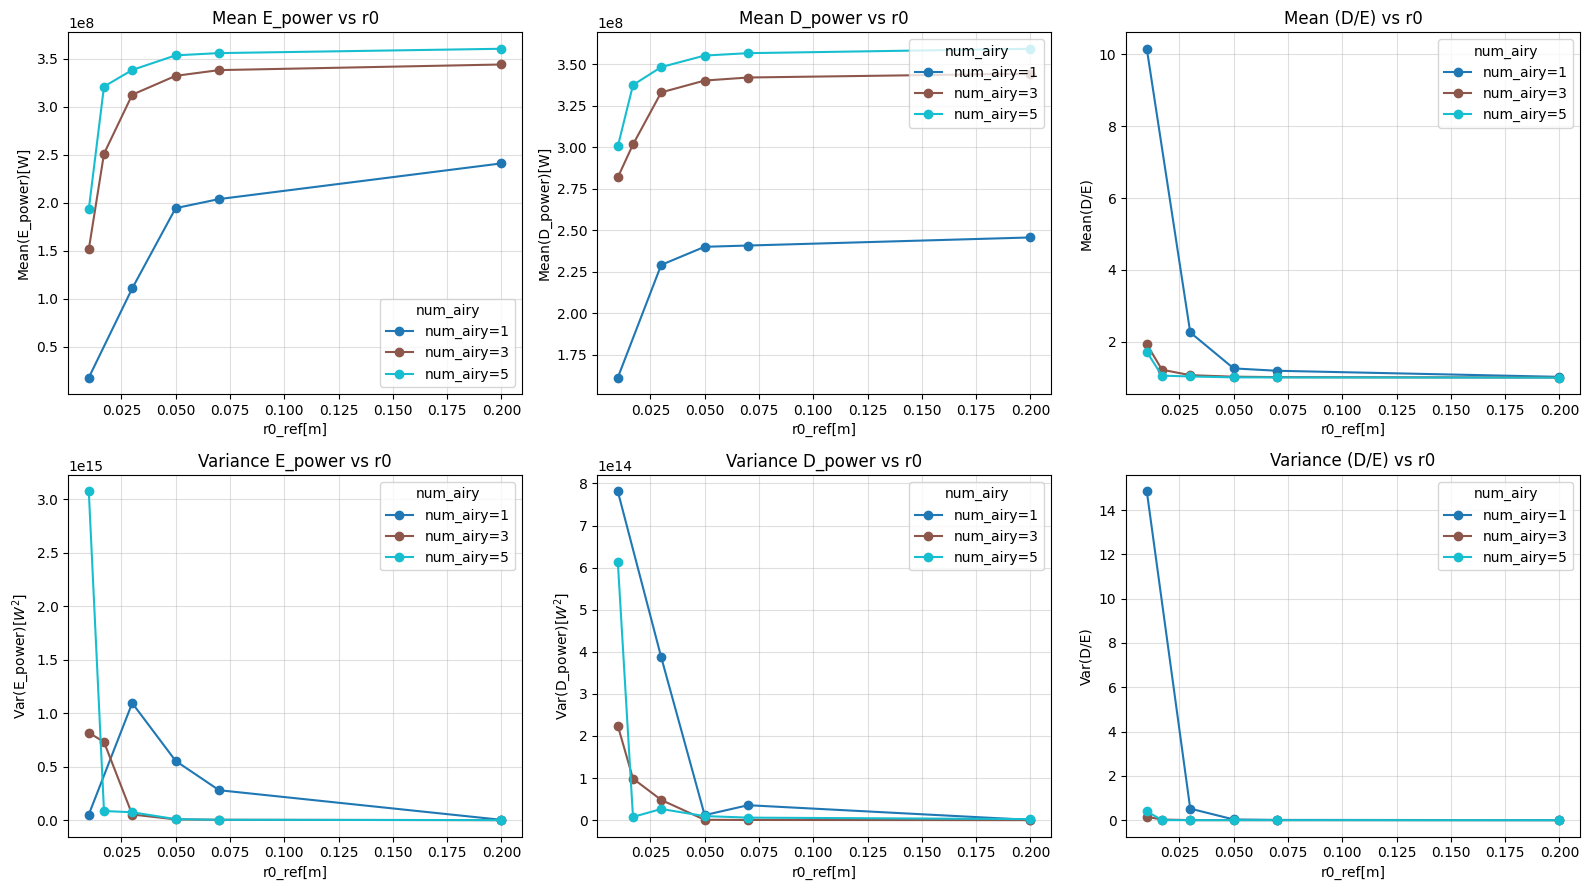

In [ ]:

# --- Load CSV ---
df = pd.read_csv("AO_simulation_log.csv")

# column names
t_col   = "timestep"
E_col   = "E_power_sum"
D_col   = "D_power_sum"
r0_col  = "r0_ref"
airy_col = "num_airy"

# compute ratio D/E safely
df = df.copy()
df["ratio_DE"] = df[D_col] / df[E_col]

# --- Compute mean & var per (r0, num_airy) ---
summary = (
    df
    .groupby([r0_col, airy_col])
    .agg(
        E_mean     = (E_col,  "mean"),
        D_mean     = (D_col,  "mean"),
        ratio_mean = ("ratio_DE", "mean"),

        E_var      = (E_col,  "var"),
        D_var      = (D_col,  "var"),
        ratio_var  = ("ratio_DE", "var"),
    )
    .reset_index()
)

# --- Prepare figure: 2 rows × 3 columns ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
(ax00, ax01, ax02), (ax10, ax11, ax12) = axes

colors = plt.cm.tab10(np.linspace(0, 1, summary[airy_col].nunique()))

# ----- Plot all num_airy curves -----
for idx, airy in enumerate(sorted(summary[airy_col].unique())):
    color = colors[idx]
    sub = summary[summary[airy_col] == airy].sort_values(by=r0_col)

    r0_vals = sub[r0_col].values

    # -------- Row 1: MEAN --------
    ax00.plot(r0_vals, sub["E_mean"], marker="o", color=color, label=f"num_airy={airy}")
    ax01.plot(r0_vals, sub["D_mean"], marker="o", color=color)
    ax02.plot(r0_vals, sub["ratio_mean"], marker="o", color=color)

    # -------- Row 2: VAR --------
    ax10.plot(r0_vals, sub["E_var"], marker="o", color=color)
    ax11.plot(r0_vals, sub["D_var"], marker="o", color=color)
    ax12.plot(r0_vals, sub["ratio_var"], marker="o", color=color)

# ----- TITLES -----
ax00.set_title("Mean E_power vs r0")
ax01.set_title("Mean D_power vs r0")
ax02.set_title("Mean (D/E) vs r0")

ax10.set_title("Variance E_power vs r0")
ax11.set_title("Variance D_power vs r0")
ax12.set_title("Variance (D/E) vs r0")

# ----- AXIS LABELS -----
ax00.set_xlabel("r0_ref[m]")
ax01.set_xlabel("r0_ref[m]")
ax02.set_xlabel("r0_ref[m]")
ax10.set_xlabel("r0_ref[m]")
ax11.set_xlabel("r0_ref[m]")
ax12.set_xlabel("r0_ref[m]")

ax00.set_ylabel("Mean(E_power)[W]")
ax10.set_ylabel("Var(E_power)[$W^2$]")

ax01.set_ylabel("Mean(D_power)[W]")
ax11.set_ylabel("Var(D_power)[$W^2$]")

ax02.set_ylabel("Mean(D/E)")
ax12.set_ylabel("Var(D/E)")

# ----- GRID & LEGEND -----
for ax in axes.ravel():
    ax.grid(True, alpha=0.4)
ax00.legend(title="num_airy")
handles, labels = ax00.get_legend_handles_labels()
ax10.legend(handles, labels, title="num_airy", loc="upper right")
ax01.legend(handles, labels, title="num_airy", loc="upper right")
ax02.legend(handles, labels, title="num_airy", loc="upper right")
ax11.legend(handles, labels, title="num_airy", loc="upper right")
ax12.legend(handles, labels, title="num_airy", loc="upper right")


# Legend only once

plt.tight_layout()
plt.show()


Found r0 values: [np.float64(0.01), np.float64(0.017), np.float64(0.03), np.float64(0.05), np.float64(0.07), np.float64(0.2)]


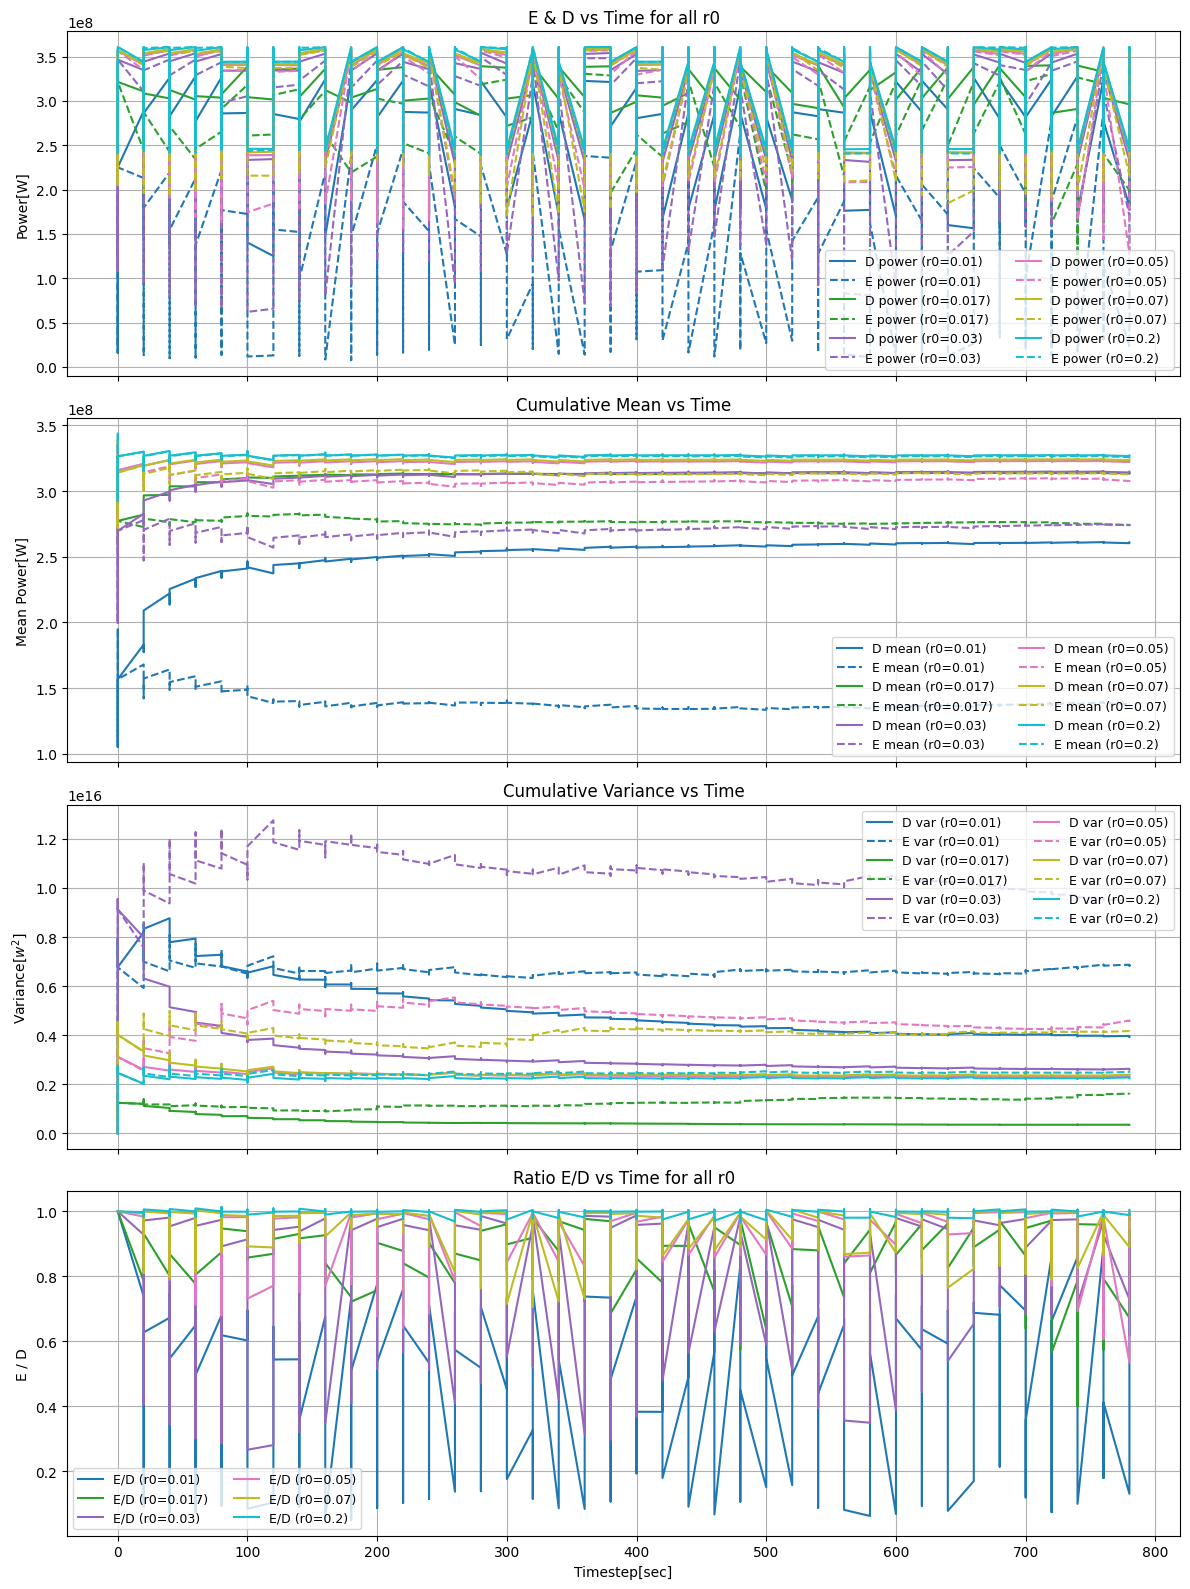

In [ ]:
df = pd.read_csv("AO_simulation_log.csv")

# שמות עמודות – עדכן אם אצלך שונים
t_col  = "timestep"
E_col  = "E_power_sum"
D_col  = "D_power_sum"

# נזהה איך קוראים לעמודת r0
if "r0_ref" in df.columns:
    r0_col = "r0_ref"
elif "r0" in df.columns:
    r0_col = "r0"
else:
    raise KeyError("לא מצאתי עמודה של r0 (נסה r0_ref או r0).")

# --- Identify unique r0 values ---
unique_r0 = sorted(df[r0_col].unique())
print("Found r0 values:", unique_r0)

# --- Prepare figure with 4 subplots ---
fig, (ax0, ax1, ax2, ax3) = plt.subplots(
    4, 1, figsize=(12, 16), sharex=True
)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_r0)))  # צבע לכל r0

# ========================
# 1) E ו-D כפונקציה של זמן
# ========================
for idx, r0 in enumerate(unique_r0):
    sub = df[df[r0_col] == r0].sort_values(by=t_col)

    t = sub[t_col].values
    E = sub[E_col].values
    D = sub[D_col].values

    color = colors[idx]

    # D power = קו ישר
    ax0.plot(t, D, '-', color=color, label=f"D power (r0={r0})")
    # E power = קו מקווקו
    ax0.plot(t, E, '--', color=color, label=f"E power (r0={r0})")

ax0.set_ylabel("Power[W]")
ax0.set_title("E & D vs Time for all r0")
ax0.grid(True)
ax0.legend(ncol=2, fontsize=9)

# ============================
# 2) תוחלת בזמן (cumulative mean)
# ============================
for idx, r0 in enumerate(unique_r0):
    sub = df[df[r0_col] == r0].sort_values(by=t_col)

    t = sub[t_col].values

    # cumulative moving average לאורך הזמן
    E_mean = sub[E_col].expanding().mean()
    D_mean = sub[D_col].expanding().mean()

    color = colors[idx]

    ax1.plot(t, D_mean, '-',  color=color, label=f"D mean (r0={r0})")
    ax1.plot(t, E_mean, '--', color=color, label=f"E mean (r0={r0})")

ax1.set_ylabel("Mean Power[W]")
ax1.set_title("Cumulative Mean vs Time")
ax1.grid(True)
ax1.legend(ncol=2, fontsize=9)

# ============================
# 3) שונות בזמן (cumulative variance)
# ============================
for idx, r0 in enumerate(unique_r0):
    sub = df[df[r0_col] == r0].sort_values(by=t_col)

    t = sub[t_col].values

    # cumulative variance לאורך הזמן
    E_var = sub[E_col].expanding().var(ddof=0)
    D_var = sub[D_col].expanding().var(ddof=0)

    color = colors[idx]

    ax2.plot(t, D_var, '-',  color=color, label=f"D var (r0={r0})")
    ax2.plot(t, E_var, '--', color=color, label=f"E var (r0={r0})")

ax2.set_ylabel("Variance[$w^2$]")
ax2.set_title("Cumulative Variance vs Time")
ax2.grid(True)
ax2.legend(ncol=2, fontsize=9)

# ============================
# 4) היחס D/E כפונקציה של זמן
# ============================
for idx, r0 in enumerate(unique_r0):
    sub = df[df[r0_col] == r0].sort_values(by=t_col)

    t = sub[t_col].values
    E = sub[E_col].values
    D = sub[D_col].values

    # להימנע מחלוקה באפס – אם יש אפסים ב-E, נשים NaN
    E_safe = np.where(E == 0, np.nan, E)
    ratio =  E_safe/D  # E/D

    color = colors[idx]
    ax3.plot(t, ratio, '-', color=color, label=f"E/D (r0={r0})")

ax3.set_xlabel("Timestep[sec]")
ax3.set_ylabel("E / D")
ax3.set_title("Ratio E/D vs Time for all r0")
ax3.grid(True)
ax3.legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()














Found r0 values: [np.float64(0.01), np.float64(0.017), np.float64(0.03), np.float64(0.05), np.float64(0.07), np.float64(0.2)]


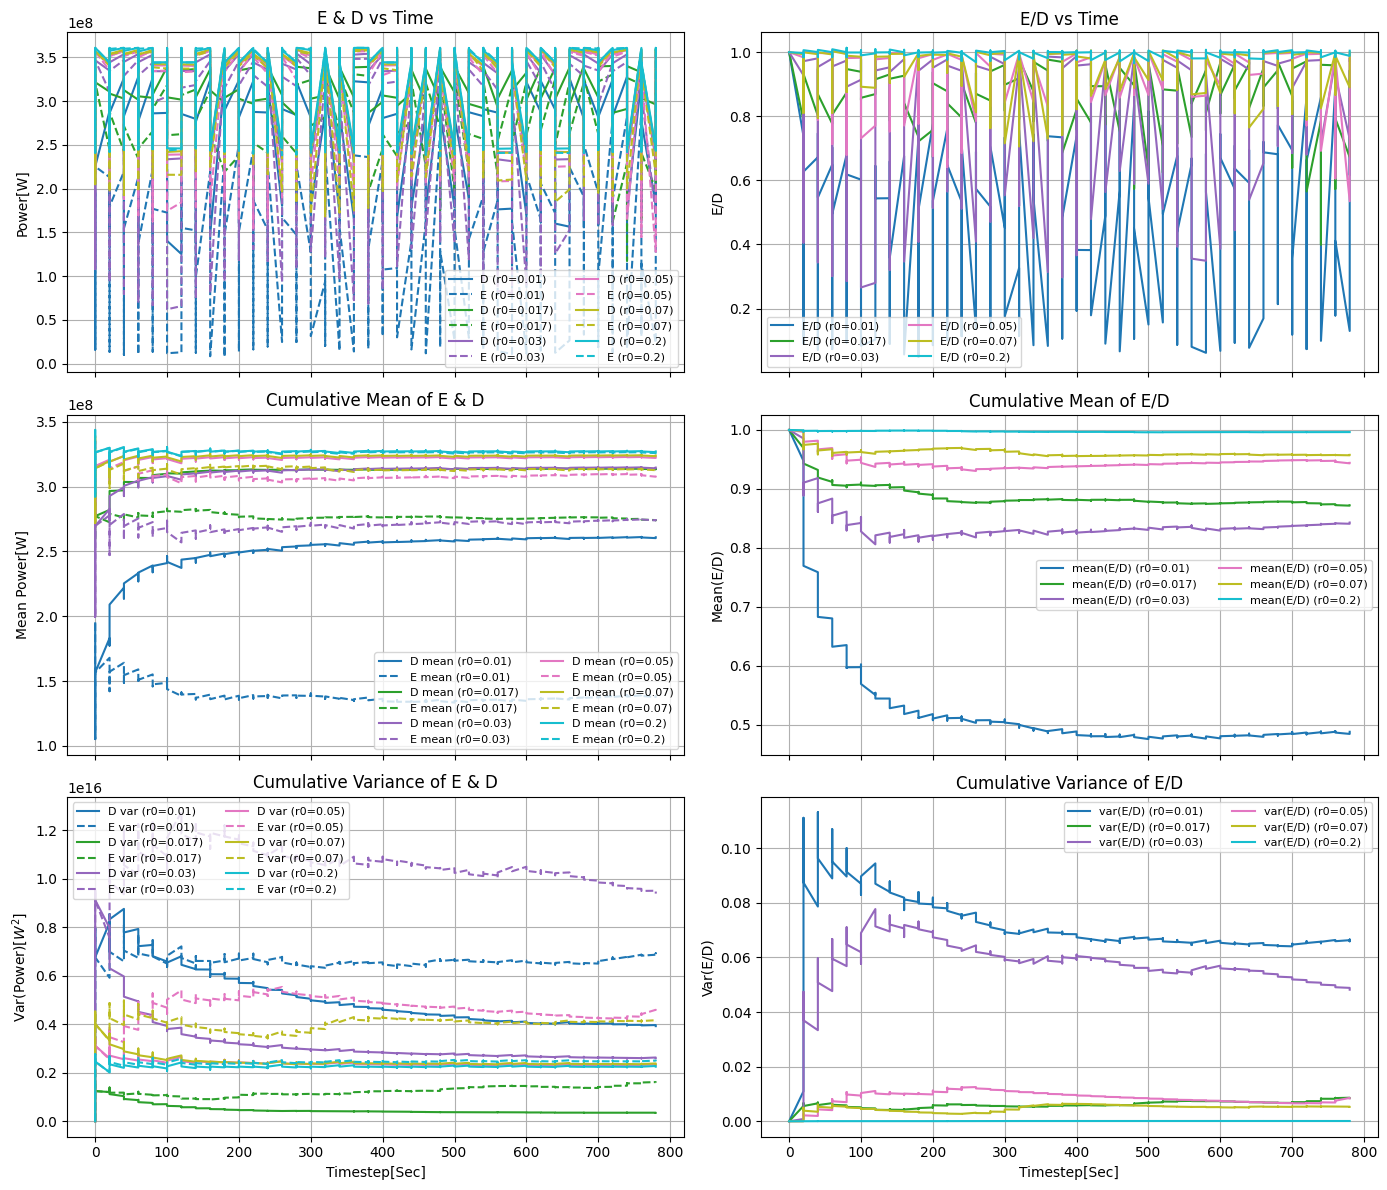

In [ ]:

# --- Load CSV ---
df = pd.read_csv("AO_simulation_log.csv")

# column names (adjust if needed)
t_col  = "timestep"
E_col  = "E_power_sum"
D_col  = "D_power_sum"

# detect r0 column
if "r0_ref" in df.columns:
    r0_col = "r0_ref"
elif "r0" in df.columns:
    r0_col = "r0"
else:
    raise KeyError("r0 column not found (expected 'r0_ref' or 'r0').")

unique_r0 = sorted(df[r0_col].unique())
print("Found r0 values:", unique_r0)

# --- precompute data per r0 ---
data = {}
for r0 in unique_r0:
    sub = df[df[r0_col] == r0].sort_values(by=t_col)

    t = sub[t_col].values
    E = sub[E_col].values
    D = sub[D_col].values

    # avoid division by zero
    E_safe = np.where(E == 0, np.nan, E)
    ratio =  E_safe/D  # E/D

    # cumulative mean (expanding)
    E_mean = sub[E_col].expanding().mean().values
    D_mean = sub[D_col].expanding().mean().values
    ratio_mean = pd.Series(ratio).expanding().mean().values

    # cumulative variance (expanding)
    E_var = sub[E_col].expanding().var(ddof=0).values
    D_var = sub[D_col].expanding().var(ddof=0).values
    ratio_var = pd.Series(ratio).expanding().var(ddof=0).values

    data[r0] = {
        "t": t,
        "E": E,
        "D": D,
        "ratio": ratio,
        "E_mean": E_mean,
        "D_mean": D_mean,
        "ratio_mean": ratio_mean,
        "E_var": E_var,
        "D_var": D_var,
        "ratio_var": ratio_var,
    }

# --- create 3x2 figure ---
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
(ax00, ax01), (ax10, ax11), (ax20, ax21) = axes

colors = plt.cm.tab10(np.linspace(0, 1, len(unique_r0)))

# ----------------- row 1: raw D & E, and ratio E/D -----------------
for idx, r0 in enumerate(unique_r0):
    color = colors[idx]
    d = data[r0]

    # col 1: D & E vs time
    ax00.plot(d["t"], d["D"], '-',  color=color, label=f"D (r0={r0})")
    ax00.plot(d["t"], d["E"], '--', color=color, label=f"E (r0={r0})")

    # col 2: ratio E/D vs time
    ax01.plot(d["t"], d["ratio"], '-', color=color, label=f"E/D (r0={r0})")

ax00.set_ylabel("Power[W]")
ax00.set_title("E & D vs Time")
ax00.grid(True)
ax00.legend(ncol=2, fontsize=8)

ax01.set_ylabel("E/D")
ax01.set_title("E/D vs Time")
ax01.grid(True)
ax01.legend(ncol=2, fontsize=8)

# ------------- row 2: cumulative mean of D & E, and of ratio ---------
for idx, r0 in enumerate(unique_r0):
    color = colors[idx]
    d = data[r0]

    # col 1: cumulative mean of D & E
    ax10.plot(d["t"], d["D_mean"], '-',  color=color, label=f"D mean (r0={r0})")
    ax10.plot(d["t"], d["E_mean"], '--', color=color, label=f"E mean (r0={r0})")

    # col 2: cumulative mean of ratio
    ax11.plot(d["t"], d["ratio_mean"], '-', color=color, label=f"mean(E/D) (r0={r0})")

ax10.set_ylabel("Mean Power[W]")
ax10.set_title("Cumulative Mean of E & D")
ax10.grid(True)
ax10.legend(ncol=2, fontsize=8)

ax11.set_ylabel("Mean(E/D)")
ax11.set_title("Cumulative Mean of E/D")
ax11.grid(True)
ax11.legend(ncol=2, fontsize=8)

# ------------- row 3: cumulative variance of D & E, and of ratio -----
for idx, r0 in enumerate(unique_r0):
    color = colors[idx]
    d = data[r0]

    # col 1: cumulative variance of D & E
    ax20.plot(d["t"], d["D_var"], '-',  color=color, label=f"D var (r0={r0})")
    ax20.plot(d["t"], d["E_var"], '--', color=color, label=f"E var (r0={r0})")

    # col 2: cumulative variance of ratio
    ax21.plot(d["t"], d["ratio_var"], '-', color=color, label=f"var(E/D) (r0={r0})")

ax20.set_xlabel("Timestep[Sec]")
ax20.set_ylabel("Var(Power)[$W^2$]")
ax20.set_title("Cumulative Variance of E & D")
ax20.grid(True)
ax20.legend(ncol=2, fontsize=8)

ax21.set_xlabel("Timestep[Sec]")
ax21.set_ylabel("Var(E/D)")
ax21.set_title("Cumulative Variance of E/D")
ax21.grid(True)
ax21.legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()


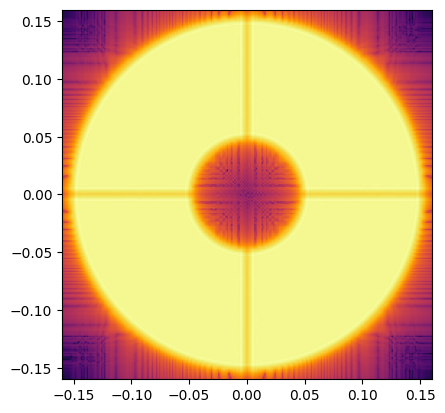

In [ ]:
imshow_field(np.log10((wf_wfs_after_atmos).power/(wf_wfs_after_atmos).power.max()),cmap="inferno")

In [ ]:
fried_parameter =0.01
Cn_squared = Cn_squared_from_fried_parameter(fried_parameter, 500e-9)
layer = InfiniteAtmosphericLayer(pupil_grid, Cn_squared, outer_scale, velocity)
layer.reset()
deformable_mirror.flatten()

gain = 0.3
leakage = 0.01
num_iterations = 750
burn_in_iterations = 5

coro = PerfectCoronagraph(ap, 4)

long_exposure = focal_grid.zeros()
long_exposure_coro = focal_grid.zeros()

# Set up animation
plt.figure(figsize=(8, 8))
anim = FFMpegWriter('AO_simulation_with_turbulence.mp4', framerate=10)

for timestep in tqdm(range(num_iterations)):
    layer.t = timestep * delta_t

    # Propagate through atmosphere and deformable mirror.
    wf_wfs_after_atmos = layer(wf_wfs)
    wf_wfs_after_dm = deformable_mirror(wf_wfs_after_atmos)

    # Propagate through SH-WFS
    wf_wfs_on_sh = shwfs(magnifier(wf_wfs_after_dm))

    # Propagate the NIR wavefront
    wf_sci_focal_plane = propagator(deformable_mirror(layer(wf_sci)))
    wf_sci_coro = propagator(coro(deformable_mirror(layer(wf_sci))))

    # Read out WFS camera
    camera.integrate(wf_wfs_on_sh, delta_t)
    wfs_image = camera.read_out()
    wfs_image = large_poisson(wfs_image).astype('float')

    # Accumulate long-exposure image
    if timestep >= burn_in_iterations:
        long_exposure += wf_sci_focal_plane.power / (num_iterations - burn_in_iterations)
        long_exposure_coro += wf_sci_coro.power / (num_iterations - burn_in_iterations)

    # Calculate slopes from WFS image
    slopes = shwfse.estimate([wfs_image + 1e-10])
    slopes -= slopes_ref
    slopes = slopes.ravel()

    # Perform wavefront control and set DM actuators
    deformable_mirror.actuators = (1 - leakage) * deformable_mirror.actuators - gain * reconstruction_matrix.dot(slopes)

    # Plotting
    if timestep % 20 == 0:
        plt.clf()

        plt.suptitle('Timestep %d / %d' % (timestep, num_iterations))

        plt.subplot(2,2,1)
        plt.title('DM surface [$\\mu$m]')
        imshow_field(deformable_mirror.surface * 1e6, cmap='RdBu', vmin=-2, vmax=2, mask=ap)
        plt.colorbar()

        plt.subplot(2,2,2)
        plt.title('WFS image [counts]')
        imshow_field(wfs_image, cmap='inferno')
        plt.colorbar()

        plt.subplot(2,2,3)
        plt.title('Instantaneous PSF at 2.2$\\mu$m [log]')
        imshow_field(np.log10(wf_sci_focal_plane.power/ wf_sci_focal_plane.power.max()), vmin=-6, vmax=0, cmap='inferno') #
        plt.colorbar()

        if timestep >= burn_in_iterations:
            plt.subplot(2,2,4)
            plt.title('Average PSF at 2.2$\\mu$m [log]')
            imshow_field(np.log10(long_exposure_coro / long_exposure.max()), vmin=-6, vmax=0, cmap='inferno')
            plt.colorbar()

        anim.add_frame()

plt.close()
anim.close()

# Show created animation
anim


  0%|          | 0/750 [00:00<?, ?it/s]

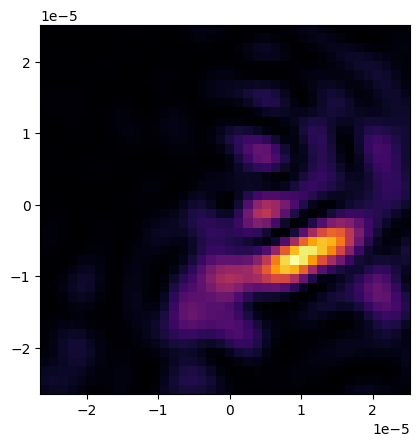

In [ ]:
wf_sci_focal_plane = propagator(deformable_mirror(layer(wf_sci)))
#imshow_field(np.log10(wf_sci_focal_plane.power / wf_sci_focal_plane.power.max()), vmin=-6, vmax=0, cmap='inferno')
wf11= layer(wf_wfs)
wf12=propagator(wf11)
imshow_field(wf12.power / wf12.power.max(), cmap='inferno')


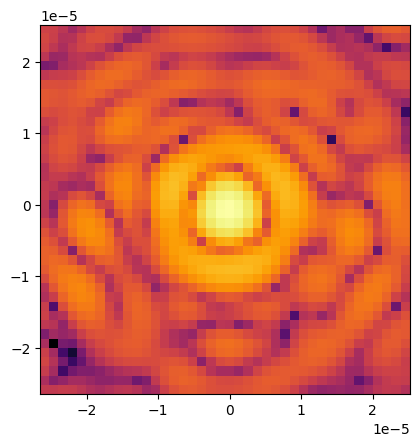

In [ ]:
wf_sci_focal_plane = propagator(deformable_mirror(layer(wf_sci)))
imshow_field(np.log10(wf_sci_focal_plane.power)/np.log10(wf_sci_focal_plane.power).max() , cmap='inferno')


In [ ]:
print(deformable_mirror)

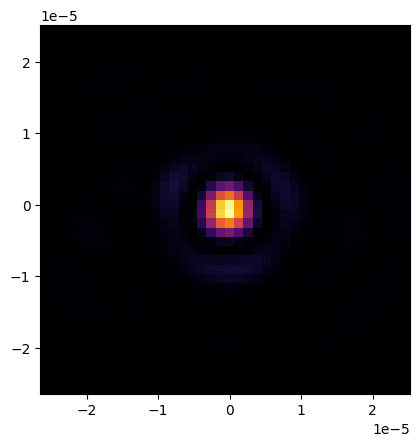

In [ ]:
L0 = 40.0          # [m]
tau0 = 5e-3        # [s]
lam_ref = 500e-9   # [m]
r0_ref=0.017
wavelength=1.55e-6
r0 = r0_ref * (wavelength / lam_ref) ** (6.0 / 5.0)    
# r0 = seeing_to_fried_parameter(seeing)                # [m] at 500 nm
Cn2 = Cn_squared_from_fried_parameter(r0_ref, lam_ref)  
Cn2
wf_sci_focal_plane = propagator(deformable_mirror(layer(wf_sci)))
imshow_field(wf_sci_focal_plane.power/wf_sci_focal_plane.power.max() , cmap='inferno')


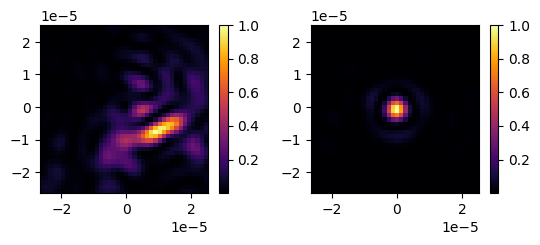

In [ ]:
wf_wfs_after_atmos = layer(wf_wfs)
wf_aa=propagator(wf_wfs_after_atmos)
plt.subplot(2,2,1)
imshow_field(wf_aa.power/wf_aa.power.max(),cmap="inferno")
plt.colorbar()
plt.subplot(2,2,2)
imshow_field(wf_sci_focal_plane.power/wf_sci_focal_plane.power.max() , cmap='inferno')
plt.colorbar()



In [ ]:
c=0
d=0
a2="1.55e-06,0.017,999,5,0.9262265307446073,0.9262265307446073,1.0,0.8232644826147609,0.002378776157471889,0.0028894434385371335,82.32644826147613,0.8667299501146477,2025-11-28 19:06:02"
a="wavelength,r0_ref_val,run_num,power_in_bucket_before,total_power_before,precentage_before,total_power_after,precentage_after,conservation_of_energy,num_airy,power_after_OA,power_in_bucket_after,time"
for w in a:
    if w==',':
        c=c+1
print(c)
for w in a2:
    if w==',':
        d=d+1
print(d)

12
12
